In [ ]:
from pathlib import Path
from typing import Dict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from textblob import TextBlob

In [23]:
# load data
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
DATA_DIR = BASE_DIR / "data"


def load_csv(filename: str) -> pd.DataFrame:
	file_path = DATA_DIR / filename
	return pd.read_csv(file_path)


def load_all_dataframes() -> Dict[str, pd.DataFrame]:
	return {
		"faculty_ratings": load_csv("umsi-faculty-ratings.csv"),
		"rating_posts": load_csv("umsi-rating-posts.csv"),
		"atlas": load_csv("instructor-data.csv"),
	}


dataframes = load_all_dataframes()
faculty_ratings = dataframes["faculty_ratings"]
rating_posts = dataframes["rating_posts"]
atlas = dataframes["atlas"]

# Keep post id, and map faculty_id to id so merge can be on "id"
rating_posts_for_merge = rating_posts.rename(columns={"id": "post_id", "faculty_id": "id"})

merged_df = rating_posts_for_merge.merge(
	faculty_ratings,
	on="id",
	how="left",
)

In [24]:
pd.set_option("display.max_columns", None)
display(merged_df.head(1))

merged_df.info()

,post_id,id,text,score,date,course,tough_grader_x,get_ready_to_read_x,participation_matters_x,extra_credit_x,group_projects_x,amazing_lectures_x,clear_grading_criteria_x,gives_good_feedback_x,inspirational_x,lots_of_homework_x,hilarious_x,beware_of_pop_quizzes_x,so_many_papers_x,caring_x,respected_x,lecture_heavy_x,test_heavy_x,graded_by_few_things_x,accessible_outside_class_x,online_savvy_x,name,role,rating_url,num_ratings,overall_rating,would_take_again,level_of_difficulty,tough_grader_y,get_ready_to_read_y,participation_matters_y,extra_credit_y,group_projects_y,amazing_lectures_y,clear_grading_criteria_y,gives_good_feedback_y,inspirational_y,lots_of_homework_y,hilarious_y,beware_of_pop_quizzes_y,so_many_papers_y,caring_y,respected_y,lecture_heavy_y,test_heavy_y,graded_by_few_things_y,accessible_outside_class_y,online_savvy_y
0,42093194,101,I found Katie to be extremely passive-aggressi...,2,2025-12-08,SI110,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Katie LaPlant,Lecturer I,https://www.ratemyprofessors.com/professor/308...,7.0,1.3,0.0,4.1,1,1,1,1,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0


<class 'pandas.DataFrame'>
RangeIndex: 1387 entries, 0 to 1386
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   post_id                     1387 non-null   int64  
 1   id                          1387 non-null   int64  
 2   text                        1387 non-null   str    
 3   score                       1387 non-null   int64  
 4   date                        1387 non-null   str    
 5   course                      1387 non-null   str    
 6   tough_grader_x              1387 non-null   int64  
 7   get_ready_to_read_x         1387 non-null   int64  
 8   participation_matters_x     1387 non-null   int64  
 9   extra_credit_x              1387 non-null   int64  
 10  group_projects_x            1387 non-null   int64  
 11  amazing_lectures_x          1387 non-null   int64  
 12  clear_grading_criteria_x    1387 non-null   int64  
 13  gives_good_feedback_x       1387 non-null   

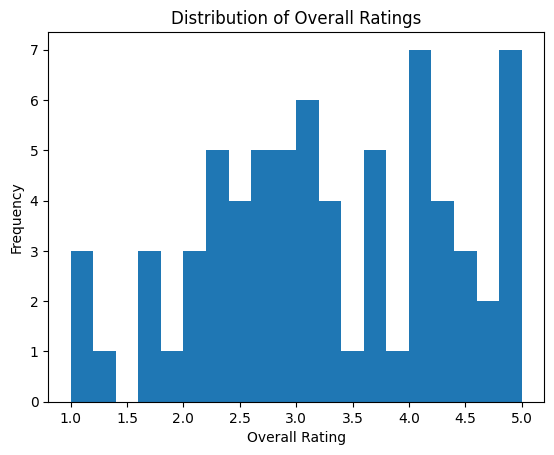

In [25]:
plt.hist(dataframes["faculty_ratings"]["overall_rating"], bins=20)
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Overall Ratings")
plt.show()

In [26]:
df_atlas = dataframes['atlas']

In [27]:
df_atlas["complete_score"] = df_atlas[["preparedness_pct", "clarity_pct", "respect_pct"]].mean(axis=1)

In [28]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1387 entries, 0 to 1386
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   post_id                     1387 non-null   int64  
 1   id                          1387 non-null   int64  
 2   text                        1387 non-null   str    
 3   score                       1387 non-null   int64  
 4   date                        1387 non-null   str    
 5   course                      1387 non-null   str    
 6   tough_grader_x              1387 non-null   int64  
 7   get_ready_to_read_x         1387 non-null   int64  
 8   participation_matters_x     1387 non-null   int64  
 9   extra_credit_x              1387 non-null   int64  
 10  group_projects_x            1387 non-null   int64  
 11  amazing_lectures_x          1387 non-null   int64  
 12  clear_grading_criteria_x    1387 non-null   int64  
 13  gives_good_feedback_x       1387 non-null   

# Problem formulation

Students struggle to choose the best professors. Universities lack scalable ways to evaluate teaching quality. Our system uses student feedback data to provide “objective” insights into professor performance.

**We will label professors good or bad only based on the ratings from rate my professor to direct class enrollement and professor reputation.**

### Target:

- Professors (directly impacted by biased reports)
- Students (indirectly manipulated by biased reports)

### Goals

- Manipulate course demand and enrollement
- Influence professor reputation

# Data Collection

# Data Analysis

Top 5 Professors by Average Score:
name
Mustafa Naseem    5.0
Elle O'Brien      5.0
Barry Fishman     5.0
Ben Green         5.0
John Thompson     5.0
Name: score, dtype: float64

Bottom 5 Professors by Average Score:
name
Gabriela Marcu       1.600000
Katie LaPlant        1.285714
Stephanie Brenton    1.000000
Cory Knobel          1.000000
Abigail Jacobs       1.000000
Name: score, dtype: float64


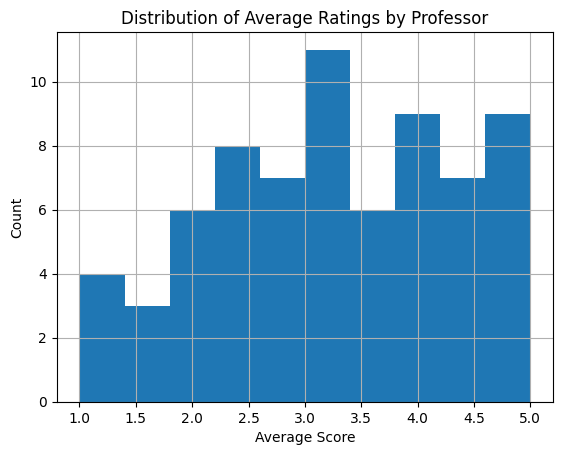

In [29]:
prof_avg = merged_df.groupby("name")["score"].mean().sort_values(ascending=False)
print("Top 5 Professors by Average Score:")
print(prof_avg.head())
print("\nBottom 5 Professors by Average Score:")
print(prof_avg.tail())

# Distribution of average scores across professors
prof_avg.hist()
plt.title("Distribution of Average Ratings by Professor")
plt.xlabel("Average Score")
plt.ylabel("Count")
plt.show()

In [30]:
def get_sentiment(text):
    if pd.isna(text):
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

merged_df["sentiment"] = merged_df["text"].apply(get_sentiment)

# Check relationship
print(merged_df[["score", "sentiment"]].corr(numeric_only=True))
display(merged_df[["text", "score", "sentiment"]].head())

              score  sentiment
score      1.000000   0.607944
sentiment  0.607944   1.000000


,text,score,sentiment
0,I found Katie to be extremely passive-aggressi...,2,-0.08125
1,She tends to be very passive aggressive during...,1,0.20000
2,The professor is awful. Escape from her if you...,1,-0.18750
3,She is very rude to students and the assignmen...,1,-0.21800
4,Prof has a lot of unrealistic expectations and...,2,0.03750


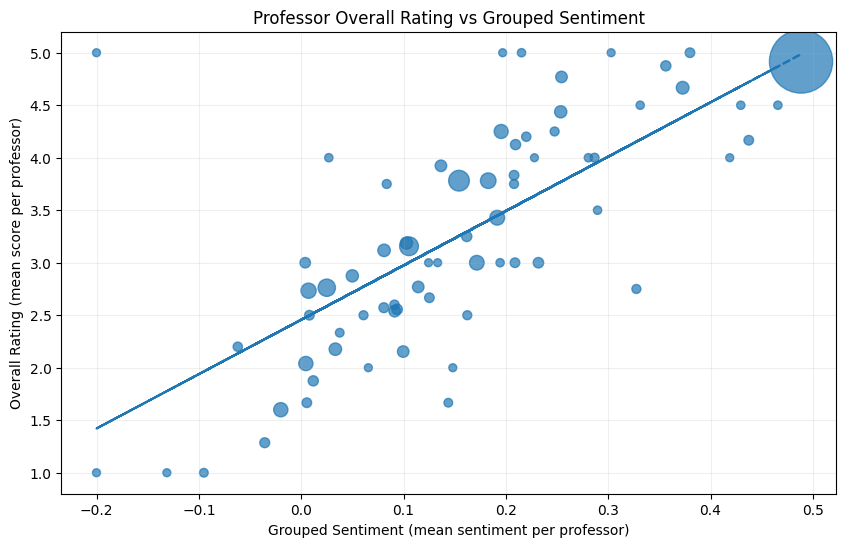

Correlation: 0.7040091692367085


,name,overall_rating,grouped_sentiment,reviews_count
48,Mustafa Naseem,5.0,0.196875,1
20,Elle O'Brien,5.0,0.215278,2
5,Barry Fishman,5.0,0.379876,6
6,Ben Green,5.0,-0.200000,1
32,John Thompson,5.0,0.302857,1


In [ ]:
professor_compare = (
    merged_df.groupby("name", as_index=False)
    .agg(
        overall_rating=("score", "mean"),
        grouped_sentiment=("sentiment", "mean"),
        reviews_count=("post_id", "count"),
    )
    .dropna(subset=["overall_rating", "grouped_sentiment"])
)

plt.figure(figsize=(10, 6))
plt.scatter(
    professor_compare["grouped_sentiment"],
    professor_compare["overall_rating"],
    s=30 + professor_compare["reviews_count"] * 3,
    alpha=0.7,
)

# Add a simple best-fit trend line
x = professor_compare["grouped_sentiment"]
y = professor_compare["overall_rating"]
if len(professor_compare) > 1:
    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, linestyle="--")

plt.title("Professor Overall Rating vs Grouped Sentiment")
plt.xlabel("Grouped Sentiment (mean sentiment per professor)")
plt.ylabel("Overall Rating (mean score per professor)")
plt.grid(alpha=0.2)
plt.show()

print("Correlation:", professor_compare[["overall_rating", "grouped_sentiment"]].corr().iloc[0, 1])
display(professor_compare.sort_values("overall_rating", ascending=False).head())

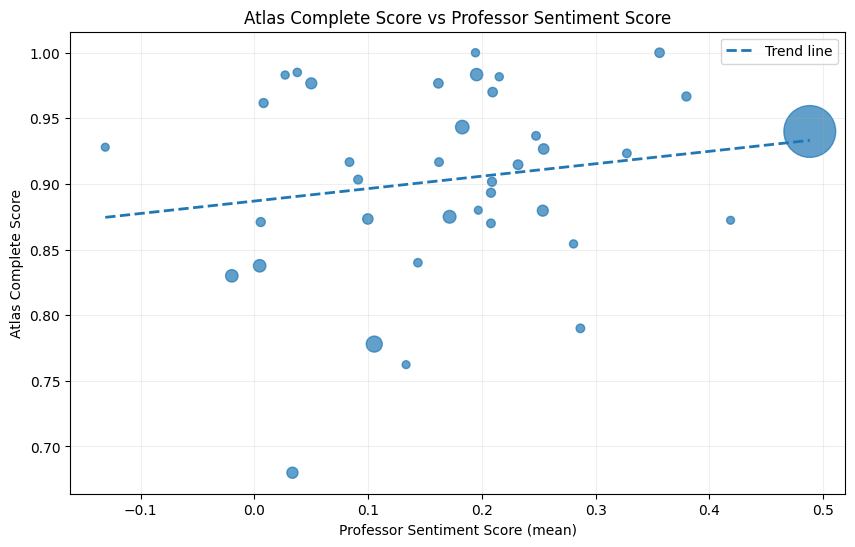

Correlation: 0.17092345678167944


,name,sentiment_score,complete_score,reviews_count
1,Alain Cohn,0.194375,1.000000,2
35,Kentaro Toyama,0.356299,1.000000,8
13,Christian Sandvig,0.037644,0.985000,3
24,Faith Sparr,0.195405,0.983333,24
19,David Wallace,0.026984,0.983000,2


In [33]:
sentiment_by_prof = (
    merged_df.groupby("id", as_index=False)
    .agg(sentiment_score=("sentiment", "mean"), reviews_count=("post_id", "count"))
)

atlas_sentiment = (
    df_atlas[["id", "name", "complete_score"]]
    .merge(sentiment_by_prof, on="id", how="inner")
    .dropna(subset=["complete_score", "sentiment_score"])
)

plt.figure(figsize=(10, 6))
plt.scatter(
    atlas_sentiment["sentiment_score"],
    atlas_sentiment["complete_score"],
    s=30 + atlas_sentiment["reviews_count"] * 2,
    alpha=0.7,
)

# Add a simple best-fit trend line
x = atlas_sentiment["sentiment_score"]
y = atlas_sentiment["complete_score"]
if len(atlas_sentiment) > 1:
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    plt.plot(x_line, m * x_line + b, linestyle="--", linewidth=2, label="Trend line")
    plt.legend()

plt.title("Atlas Complete Score vs Professor Sentiment Score")
plt.xlabel("Professor Sentiment Score (mean)")
plt.ylabel("Atlas Complete Score")
plt.grid(alpha=0.2)
plt.show()

print(
    "Correlation:",
    atlas_sentiment[["sentiment_score", "complete_score"]].corr().iloc[0, 1],
)
display(
    atlas_sentiment[["name", "sentiment_score", "complete_score", "reviews_count"]]
    .sort_values("complete_score", ascending=False)
    .head()
)

Future ideas --  integrate this into the RAG model to reduce recommendations to poorly reviewed professors.